# Stroke Prediction Data Analysis Assessment

In this notebook, we analyze the **brain_stroke.csv** dataset and
apply **logistic regression** to predict the occurrence of a stroke.

The work is divided into the following main parts:

1. **Exploratory Data Analysis (EDA)** and statistical description of the dataset.
2. **Data Preprocessing**
3. **Modeling with logistic regression** to predict the value of the variable `stroke` and
evaluate the performance of the model, taking into account that the dataset is
**imbalanced**.
4. Using **SMOTE** to address imbalance of the dataset.
5. **Final Evaluation** on the **Test** set.
6. **Logistic Regression Coefficients**
7. **Conclusions**

In [1]:
# Important libraries for data analysis and machine learning
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# For handling imbalanced datasets
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Loading the dataset
data = "brain_stroke.csv" 
df = pd.read_csv(data)

# Initial data exploration
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


From the above results, we can conclude that the variable 'bmi' has a significant number of missing values that we have to manage.

In [4]:
# Statistical summary
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 1. Exploratory Data Analysis (EDA)

The dataset includes demographic and medical characteristics of patients and also the
binary target variable **`stroke`** (1 = for patients who had a stroke, 0 = for a patients who hadn't).

Dataset variables:

- `gender` – gender
- `age` – age
- `hypertension` – 1 if the patient has hypertension, otherwise 0
- `heart_disease` – 1 if the patient has heart disease, otherwise 0
- `ever_married` – if married
- `work_type` – type of work
- `Residence_type` – urban or rural area
- `avg_glucose_level` – average glucose level
- `bmi` – body mass index
- `smoking_status` – smoking status
- `stroke` – target variable

Further, an exploration of the quality of the data is conducted.

In [5]:
# Missing values count
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

We mainly observe missing values in the variable **`bmi`**. More specifically, the variable lacks 201 values.
We will handle the missing values later in the scikit-learn pipeline,
so that the process is reproducible and "clean".

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: count, dtype: float64


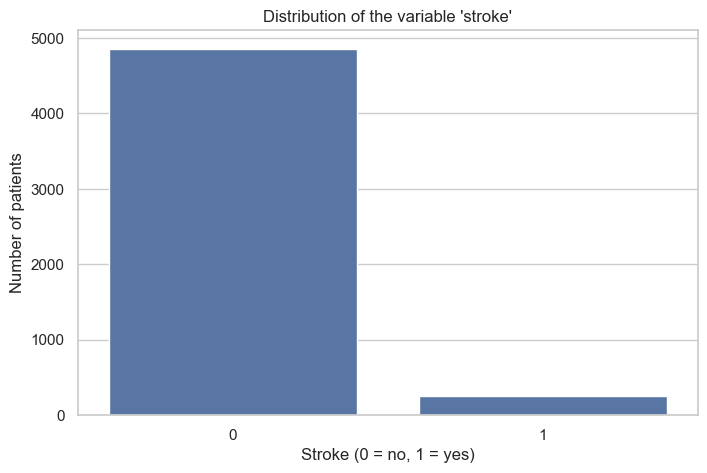

In [6]:
# Distribution of the target variable 'stroke'
stroke_counts = df["stroke"].value_counts().sort_index()
stroke_percent = stroke_counts / len(df) * 100
print(stroke_counts)
print(stroke_percent)

sns.countplot(x="stroke", data=df)
plt.title("Distribution of the variable 'stroke'")
plt.xlabel("Stroke (0 = no, 1 = yes)")
plt.ylabel("Number of patients")
plt.show()

### Note of unbalanced classes

We see that cases of patients with `stroke = 1` are much fewer than those with
`stroke = 0`. This means that the dataset is **imbalanced** and simple the
accuracy can be misleading. For this reason, we will
use additional metrics (precision, recall, F1, ROC-AUC) and techniques
such as **class weights** and **SMOTE**.

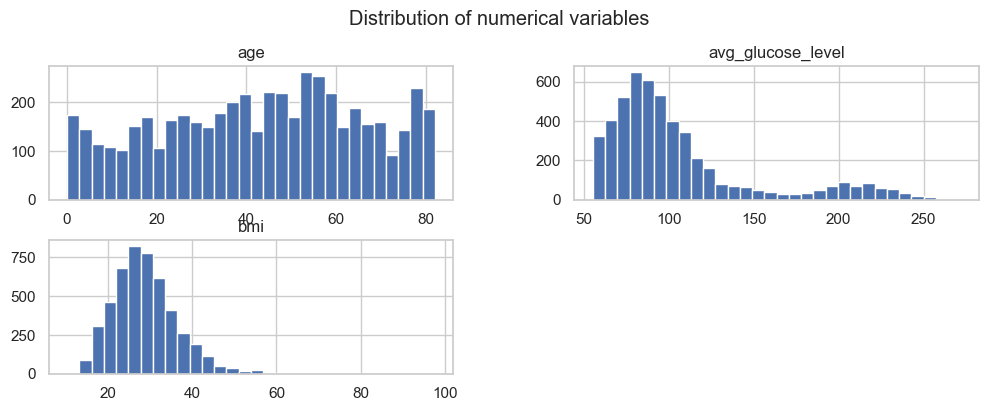

In [7]:
numeric_features = ["age", "avg_glucose_level", "bmi"]
df[numeric_features].hist(bins=30, figsize=(12, 4))
plt.suptitle("Distribution of numerical variables", y=1.02)
plt.show()

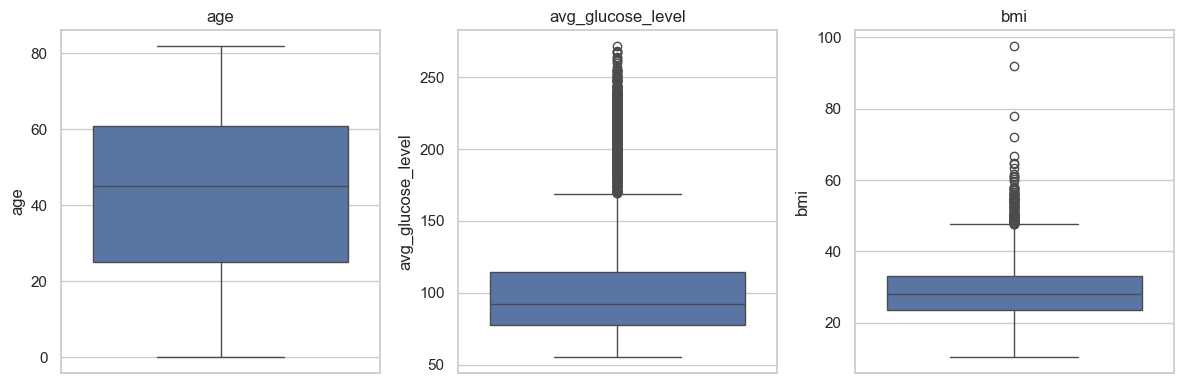

In [8]:
# Box plots for numerical features and outlier detection
plt.figure(figsize=(12,4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

The boxplots of the numerical variables reveal important information about the dispersion and the existence of extreme values in the dataset. The 'age' variable shows a **relatively uniform distribution** with no notable outliers, with a median of approximately 45–50 years and a range of values ranging from childhood to approximately 80 years. In contrast, the variables 'avg_glucose_level' and 'bmi' show strong **right asymmetry**, with a large number of values concentrated near the lower end of the scale, but also a significant number of outliers towards the upper end. Glucose has many values above 150 mg/dL, while BMI has several outliers above 40. The existence of these outliers is critical for the preprocessing process, as it can affect both model training and the interpretation of results.

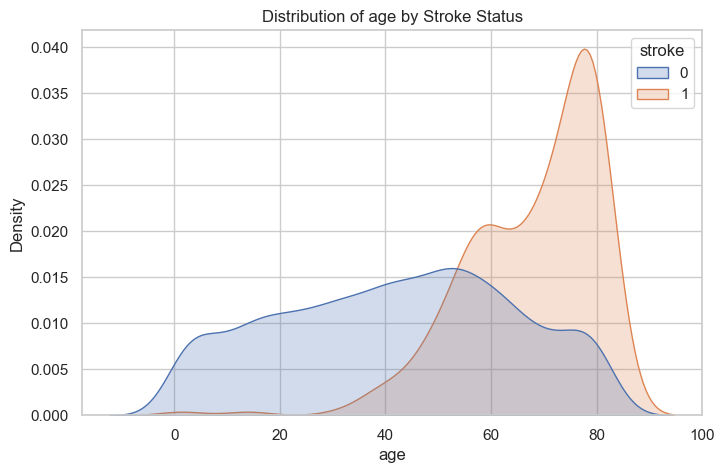

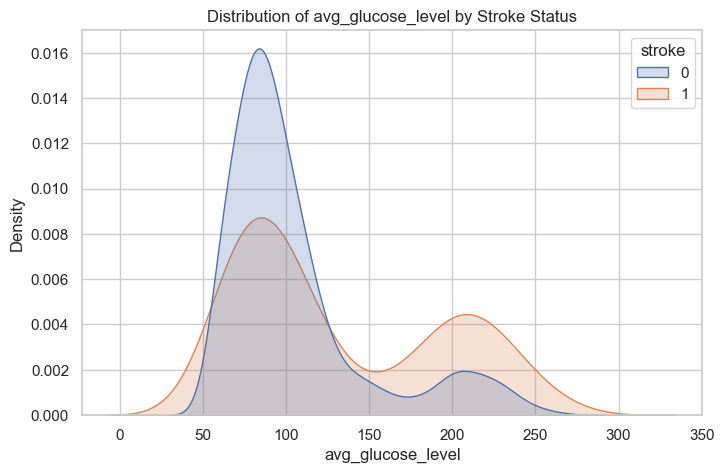

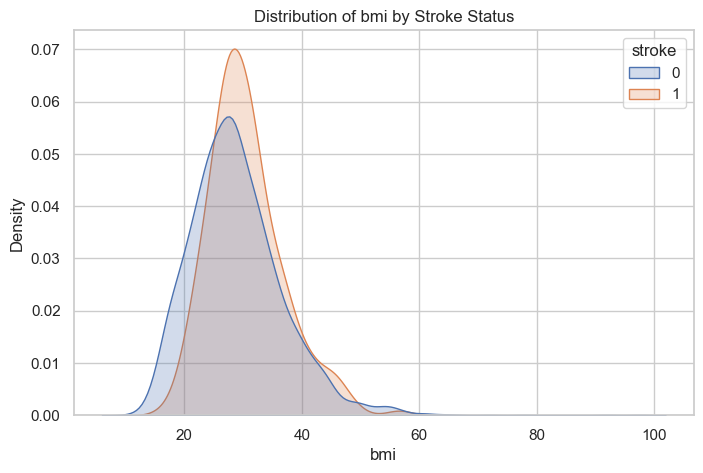

In [9]:
# KDE plots for numerical features by stroke status 
for col in numeric_features:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue="stroke", common_norm=False, fill=True)
    plt.title("Distribution of {} by Stroke Status".format(col))
    plt.show()

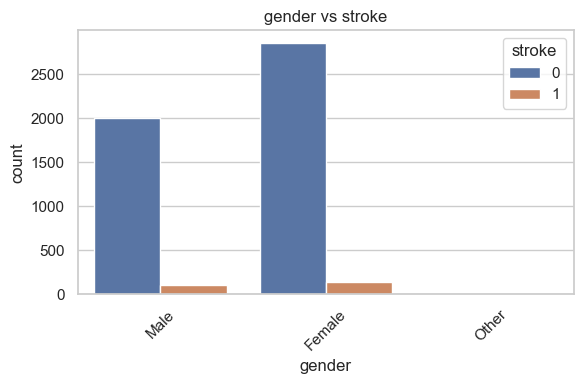

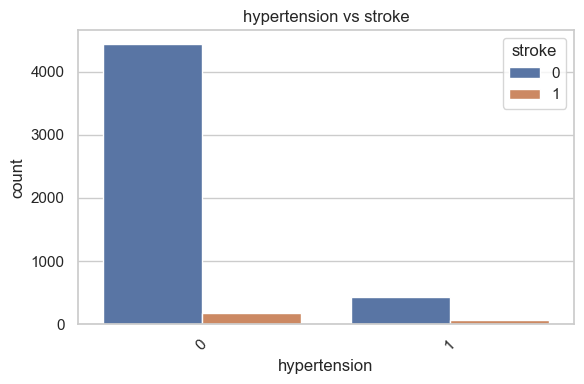

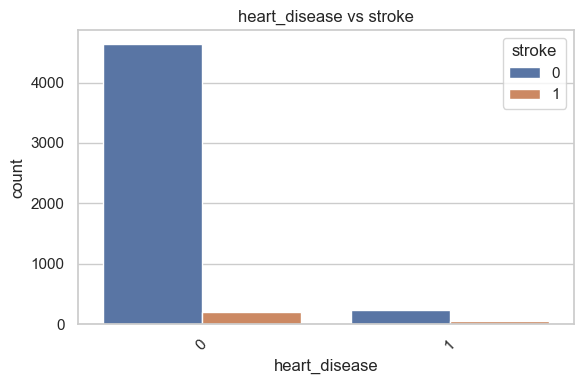

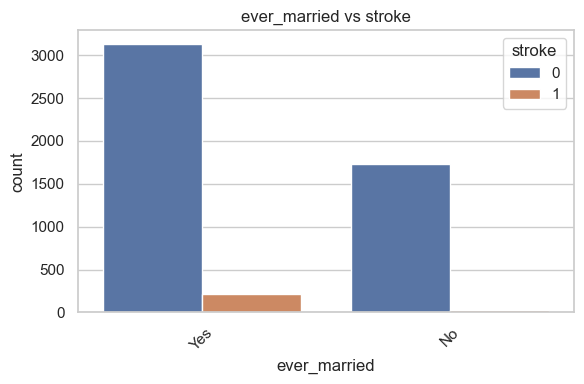

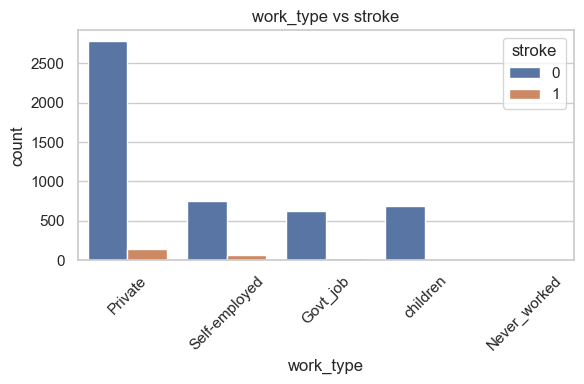

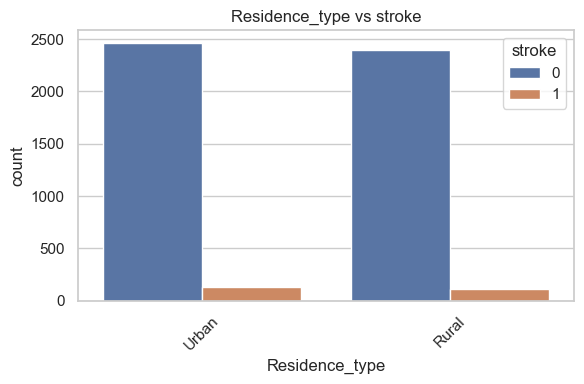

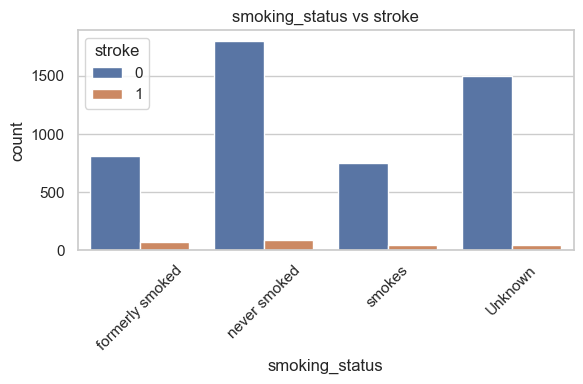

In [10]:
categorical_features = ["gender", "hypertension", "heart_disease",
                        "ever_married", "work_type", "Residence_type",
                        "smoking_status"]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="stroke")
    plt.title(f"{col} vs stroke")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

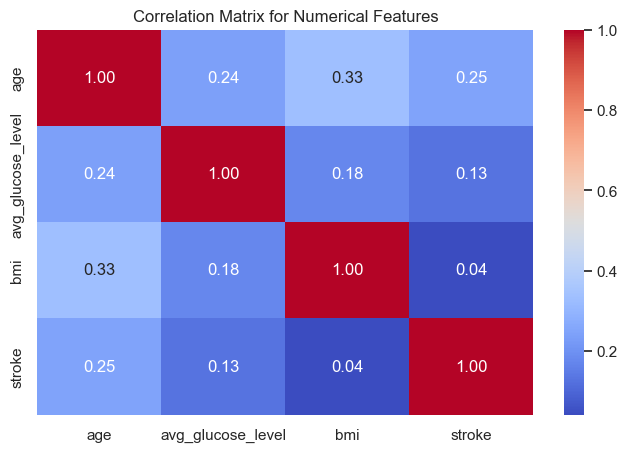

In [11]:
# Correlation matrix for numerical features
corr = df[numeric_features + ["stroke"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Numerical Features")
plt.show()

## 2. Data Preprocessing

We will prepare the data for machine learning using
**pipelines** and **ColumnTransformer** from scikit-learn:

- For numerical variables:
- Replace missing values with the mean (`SimpleImputer(strategy="mean")`)
- Normalizing features with `StandardScaler`.

- For categorical variables:
- Replacing missing values with the most frequent value (`strategy="most_frequent"`)
- One-Hot Encoding with `OneHotEncoder` (without drop to keep all categories).

We will ignore the `id` column as it does not contain information for the prediction.

In [12]:
# Preparing data for modeling
X = df.drop(columns=["stroke", "id"])
y = df["stroke"]

numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'avg_glucose_level', 'bmi']
Categorical features: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [13]:
# Splitting the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_valid.shape[0])
print("Test size:", X_test.shape[0])

Train size: 3577
Validation size: 766
Test size: 767


The data are divided into:

- **70% train set** – for training the model
- **15% validation set** – for selecting hyperparameters and experimentation
- **15% test set** – for final, "independent" evaluation of the model's performance.


The separation was done with `stratify=y` in order to maintain the ratio of
positive/negative stroke cases in each subset.


In [14]:
# Data preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


## 3. Logistic Regression Model

We start with a **Logistic Regression** model with `class_weight="balanced"`
to compensate for the imbalance of the `stroke = 1` class.
The model is integrated into a single pipeline together with preprocessing.

In [15]:
# Building the classification pipeline
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", log_reg)
])

# Training the model
clf.fit(X_train, y_train)

# Prediction on the validation set
y_valid_pred = clf.predict(X_valid)
y_valid_proba = clf.predict_proba(X_valid)[:, 1]

print("Accuracy (valid):", accuracy_score(y_valid, y_valid_pred))
print("Precision (valid):", precision_score(y_valid, y_valid_pred))
print("Recall (valid):", recall_score(y_valid, y_valid_pred))
print("F1 (valid):", f1_score(y_valid, y_valid_pred))

Accuracy (valid): 0.7389033942558747
Precision (valid): 0.1278538812785388
Recall (valid): 0.7567567567567568
F1 (valid): 0.21875


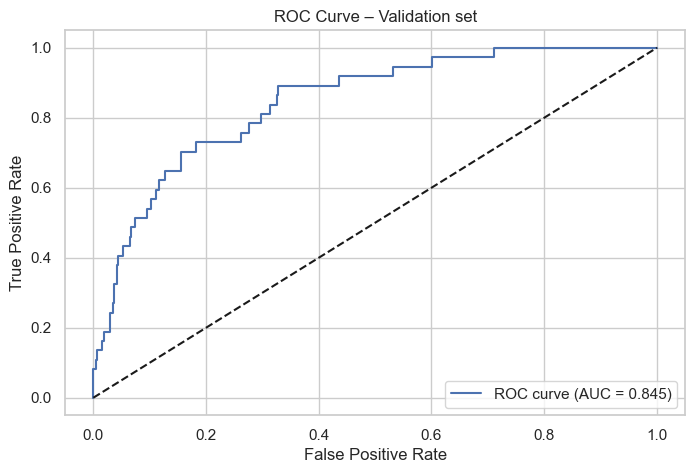

In [16]:
# ROC Curve and AUC for validation set
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Validation set")
plt.legend(loc="lower right")
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute MAE, MSE, R2 based on predicted probabilities
y_valid_proba = clf.predict_proba(X_valid)[:, 1]

mae = mean_absolute_error(y_valid, y_valid_proba)
mse = mean_squared_error(y_valid, y_valid_proba)
r2 = r2_score(y_valid, y_valid_proba)

print("Baseline Model - Additional Metrics:")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

Baseline Model - Additional Metrics:
MAE: 0.3018662661527111
MSE: 0.17083831099769203
R²: -2.7163238797227534


In [19]:
# Confusion matrix & classification report
cm = confusion_matrix(y_valid, y_valid_pred)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_valid, y_valid_pred))

Confusion matrix:
 [[538 191]
 [  9  28]]

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.74      0.84       729
           1       0.13      0.76      0.22        37

    accuracy                           0.74       766
   macro avg       0.56      0.75      0.53       766
weighted avg       0.94      0.74      0.81       766



We observe the basic metrics in the validation set:

- **Accuracy** – overall percentage of correct predictions
- **Precision** – how "clean" the positive predictions are (`stroke = 1`)
- **Recall (Sensitivity)** – how many of the actual stroke patients the model identifies
- **F1-score** – harmonic mean of precision and recall
- **ROC-AUC** – model performance across all possible thresholds

Due to unbalanced classes, we pay special attention to **Recall** in order to
reduce the number of **false negatives** (stroke patients who were not
identified).

## 4. Using SMOTE to address imbalance

In addition to `class_weight`, we can apply **SMOTE (Synthetic Minority
Over-sampling Technique)** to the training data to create
synthetic samples of the minority class (`stroke = 1`) and better balance
the training set.

In [20]:
# --- ATTENTION ---
# We apply SMOTE ONLY to the training set, after preprocessing, in order to
# avoid data leakage.

# 1. Fit the preprocessor to the train data and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Before SMOTE:", X_train_processed.shape)

# 2. SMOTE application
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("After SMOTE:", X_train_smote.shape)
print("Destribution of classes:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE: (3577, 23)
After SMOTE: (6806, 23)
Destribution of classes:
stroke
0    3403
1    3403
Name: count, dtype: int64


In [21]:
# 3. Training logistic regression on SMOTE data
log_reg_smote = LogisticRegression(max_iter=1000, solver="liblinear")

log_reg_smote.fit(X_train_smote, y_train_smote)

# 4. Αξιολόγηση στο validation set (χωρίς SMOTE εκεί!)
y_valid_pred_smote = log_reg_smote.predict(X_valid_processed)
y_valid_proba_smote = log_reg_smote.predict_proba(X_valid_processed)[:, 1]

print("Accuracy (valid, SMOTE):", accuracy_score(y_valid, y_valid_pred_smote))
print("Precision (valid, SMOTE):", precision_score(y_valid, y_valid_pred_smote))
print("Recall (valid, SMOTE):", recall_score(y_valid, y_valid_pred_smote))
print("F1 (valid, SMOTE):", f1_score(y_valid, y_valid_pred_smote))

Accuracy (valid, SMOTE): 0.7402088772845953
Precision (valid, SMOTE): 0.12844036697247707
Recall (valid, SMOTE): 0.7567567567567568
F1 (valid, SMOTE): 0.2196078431372549


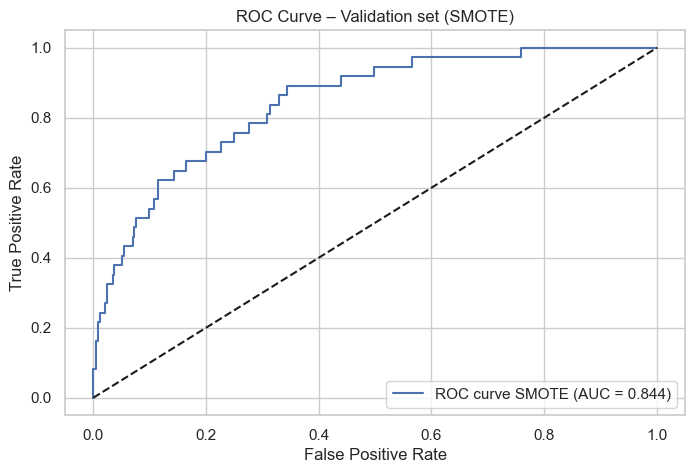

In [31]:
# ROC curve and AUC for validation set (SMOTE model)
fpr_s, tpr_s, _ = roc_curve(y_valid, y_valid_proba_smote)
roc_auc_s = auc(fpr_s, tpr_s)

plt.figure()
plt.plot(fpr_s, tpr_s, label=f"ROC curve SMOTE (AUC = {roc_auc_s:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Validation set (SMOTE)")
plt.legend(loc="lower right")
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_smote = mean_absolute_error(y_valid, y_valid_proba_smote)
mse_smote = mean_squared_error(y_valid, y_valid_proba_smote)
r2_smote = r2_score(y_valid, y_valid_proba_smote)

print("SMOTE Model - Additional Metrics:")
print("MAE:", mae_smote)
print("MSE:", mse_smote)
print("R²:", r2_smote)

SMOTE Model - Additional Metrics:
MAE: 0.29141611094956676
MSE: 0.1706436366435807
R²: -2.7120890395002735


In [26]:
# Confusion matrix & classification report με SMOTE
cm_s = confusion_matrix(y_valid, y_valid_pred_smote)
print("Confusion matrix (SMOTE):\n", cm_s)
print("\nClassification report (SMOTE):\n", classification_report(y_valid, y_valid_pred_smote))

Confusion matrix (SMOTE):
 [[539 190]
 [  9  28]]

Classification report (SMOTE):
               precision    recall  f1-score   support

           0       0.98      0.74      0.84       729
           1       0.13      0.76      0.22        37

    accuracy                           0.74       766
   macro avg       0.56      0.75      0.53       766
weighted avg       0.94      0.74      0.81       766



Although SMOTE successfully balanced the training dataset, it did not lead to any meaningful performance improvement in the validation set. The baseline Logistic Regression model (with class_weight="balanced") achieved almost identical precision, recall, F1-score and ROC-AUC values compared to the SMOTE-enhanced model. Therefore, for the final evaluation on the test set, we select the **baseline model** as it is simpler, more interpretable, and equally effective.

## 5. Final Evaluation on the Test Set

As the final model, we select the baseline Logistic Regression with class_weight="balanced" and without SMOTE, since it achieved very similar performance to the SMOTE-based model on the validation set, while being simpler and more stable. We retrain this model on the combined training and validation data and evaluate it on the independent test set.

In [27]:

# Join train + validation into a single training set
X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

# Build the final logistic regression model (baseline, without SMOTE)
final_log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

final_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", final_log_reg)
])

# Fit on the full training data (train + valid)
final_clf.fit(X_train_full, y_train_full)

# Evaluate on the test set
y_test_pred = final_clf.predict(X_test)
y_test_proba = final_clf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_proba)
roc_auc_t = auc(fpr_t, tpr_t)
print("Test ROC-AUC:", roc_auc_t)


Test Accuracy: 0.7157757496740548
Test Precision: 0.128099173553719
Test Recall: 0.8157894736842105
Test F1: 0.22142857142857142
Test ROC-AUC: 0.8339831059129303


In [28]:
# Confusion matrix & classification report for test set
cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix (test):\n", cm_test)
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred))

Confusion matrix (test):
 [[518 211]
 [  7  31]]

Classification report (test):
               precision    recall  f1-score   support

           0       0.99      0.71      0.83       729
           1       0.13      0.82      0.22        38

    accuracy                           0.72       767
   macro avg       0.56      0.76      0.52       767
weighted avg       0.94      0.72      0.80       767



## 6. Logistic Regression Coefficients

To understand which characteristics are most closely related to the
probability of stroke in patients, we examine the model's **coefficients**.

**Important Note:** The coefficients correspond to the **transformed/coded
features**, so the interpretation is qualitative.


In [36]:
# Get feature names after one-hot encoding
ohe = preprocessor.named_transformers_["cat"]["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([numeric_features, cat_feature_names])

# Extract coefficients from final model (baseline Logistic Regression)
coefficients = clf.named_steps["classifier"].coef_.flatten()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df.head(20)


,feature,coefficient
0,age,1.901475
16,work_type_children,0.912933
22,smoking_status_smokes,0.271819
1,avg_glucose_level,0.196428
7,hypertension_1,0.174806
9,heart_disease_1,0.057956
20,smoking_status_formerly smoked,0.043968
3,gender_Female,0.039138
2,bmi,0.030450
5,gender_Other,-0.039875


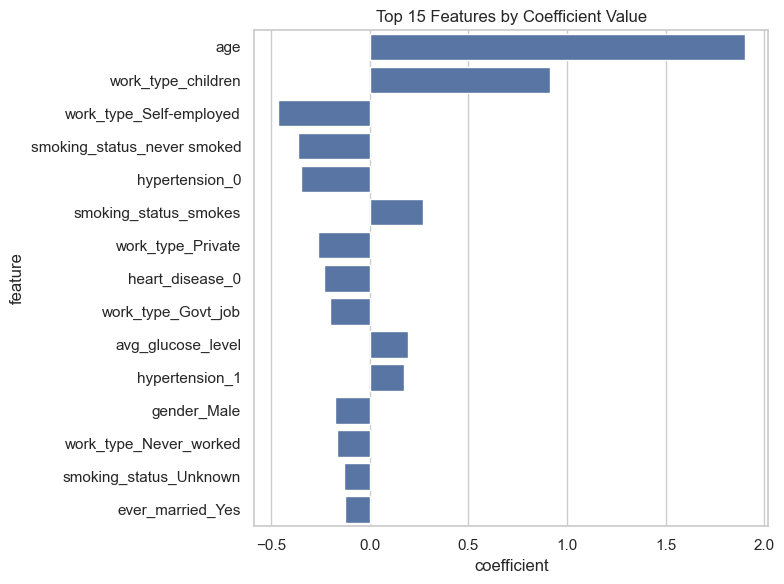

In [37]:
# Plotting the top positive and negative coefficients
top_n = 15
coef_df_sorted = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,6))
sns.barplot(x="coefficient", y="feature", data=coef_df_sorted.head(top_n))
plt.title(f"Top {top_n} Features by Coefficient Value")
plt.tight_layout()
plt.show()

To better understand which features contribute most to the model’s predictions, we examined the learned coefficients of the Logistic Regression model. A positive coefficient indicates that the feature increases the log-odds of stroke, while a negative coefficient decreases it.

The most influential feature was **age**, which strongly increases the probability of stroke, consistent with clinical findings. Other positive contributors include smoking status, hypertension, and average glucose level, all of which are well-known cardiovascular risk factors.

Categorical variables such as work type and residence type also show effects, although their interpretation requires caution due to one-hot encoding and potential dataset bias.

Features with coefficients close to zero have minimal predictive power, while negative coefficients slightly reduce the likelihood of stroke. Overall, the coefficient analysis supports the medical understanding of stroke risk factors, confirming that the model is learning meaningful relationships from the data.